In [91]:
import numpy as np
from scipy.integrate import solve_ivp, quad, cumulative_trapezoid
from scipy.constants import G
from matplotlib import pyplot as plt
from matplotlib.scale import LogScale

In [92]:
# Constants
Omega_r0 = 9.89e-5
Omega_m0 = 0.3
Omega_phi0 = 1- Omega_r0-Omega_m0
Omega_b0 = 0.05
h = 0.65
w_r = 1/3
z_dec = 1100

In [93]:
def rho_r(a):
    return 3*Omega_r0*a**(-4)

def rho_m(a):
    return 3*Omega_m0*a**(-3)

In [94]:
# Step function way
def calculate_w_phi_square(z, zmin=8, zmax=25, wmax = 1):
    if zmin<z<zmax:
        return wmax
    else:
        return -1


# Cool guy way
def calculate_w_phi(z, zmin, zmax, wmax = 1, width=0.8):
    
    # Smooth step up at z=23 (from -1 to 1)
    step_up = 0.5 * (1 - np.tanh((z - zmax) / (3*width)))
    
    # Smooth step down at z=5 (from 1 to -1)  
    step_down = 0.5 * (1 - np.tanh((zmin - z) / width))
    
    # Combine: -1 outside, +1 inside [5,25]
    w = -1 + 2 * step_up * step_down
    
    return w


z_test = 30
zmin_test = 5
zmax_test = 23
print(f"If z is {z_test} then w_phi is: {calculate_w_phi(z_test, zmin_test, zmax_test)}.")

If z is 30 then w_phi is: -0.9941605004152156.


In [174]:
def ode_system(eta, state, zmin, zmax, wmax=1, w_phi_function):
    
    rho_phi, H, a, t, hs = state
    
    z_current = (1/a)-1
    rho_r_current = rho_r(a)
    R = (30230*Omega_b0 * h**2)/(1+z_current)
    cs = 1/(np.sqrt(3*(1+R)))

    if wfun == "smooth":
        w_phi = calculate_w_phi(z_current, zmin, zmax, wmax, width=0.8)
    
    elif wfun == "square":
        w_phi = calculate_w_phi_square(z_current, zmin, zmax, wmax)
    
    drho_phi_deta = -3*a*H*(1+w_phi)*rho_phi
    dH_deta = -(3/2)*a*H**2-(a/2)*(w_r * rho_r_current+w_phi*rho_phi)
    da_deta = a**2*H
    dt_deta = a
    dhs_deta = cs
    
    return [drho_phi_deta, dH_deta, da_deta, dt_deta, dhs_deta]

initial_state = [3*Omega_phi0, 1.0, 1.0, 0.96, 0]

In [183]:
eta_0 = 0
eta_total = 5
eta_span = [0, -eta_total]
eta_eval = np.linspace(0, -eta_total, 100000)

solution = solve_ivp(
    ode_system,
    eta_span,
    initial_state,
    t_eval = eta_eval,
    method = 'BDF',
    args = (5,25, 1, "smooth"),
    rtol = 1e-10,
    atol = 1e-12
    )

In [184]:
def calculate_z_vals(aValues):
    z_vals = 1/aValues - 1
    opz_vals = 1/aValues
    return z_vals, opz_vals

def calculate_density_parameters(rhoPhiValues, rhoMValues, rhoRValues, hValues):
    omega_phis = rhoPhiValues/(3*hValues**2)
    omega_ms = rhoMValues/(3*hValues**2)
    omega_rs = rhoRValues/(3*hValues**2)
    return omega_phis, omega_ms, omega_rs

def calculate_q(omegaR, omegaM, wPhi, omegaPhi):
    return omegaR + (1/2) * omegaM + (1/2) * (1 + 3 * wPhi) * omegaPhi

def calculate_dtheta_deta(aValues, wPhi, rhoPhi):
    return aValues * np.sqrt((1 + wPhi) * rhoPhi)

def calculate_w_phi_average(omegaPhi, wPhi, space):
    numerator = cumulative_trapezoid(omegaPhi[::-1] * wPhi[::-1], space, initial = 0)
    denominator = cumulative_trapezoid(omegaPhi[::-1], space, initial=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        wphiavg =  numerator / denominator
    return wphiavg[::-1]

def calculate_zDec(zValues):
    idxDec = np.argmin(np.abs(zValues-z_dec)) #Index of z_dec
    return idxDec

def calculate_parameter_Dec(index, parameter):
    return parameter[index]

def calculate_lA(index, space, hsValues):
    eta_dec = -calculate_parameter_Dec(index, space)
    hs_dec = calculate_parameter_Dec(index, hsValues) - hsValues[-1]
    return np.pi * eta_dec/hs_dec

In [185]:
# Unpack
rho_phi_values = solution.y[0]
H_values = solution.y[1]
a_values = solution.y[2]
t_values = solution.y[3]
hs_values = solution.y[4]

z_values, oneplusz_values = calculate_z_vals(a_values)
w_phi_values = np.vectorize(calculate_w_phi)(z_values, 5, 23)

# Densities
Omega_phi, Omega_m, Omega_r = calculate_density_parameters(rho_phi_values, 
                                                           rho_m(a_values), 
                                                           rho_r(a_values),
                                                           H_values)

# Derived Quantities
q = calculate_q(Omega_r, Omega_m, w_phi_values, Omega_phi)
dtheta_deta = calculate_dtheta_deta(a_values, w_phi_values, rho_phi_values)

# w_phi_average 
w_phi_average = calculate_w_phi_average(Omega_phi, w_phi_values, solution.t)

# Decoupling
idx_zdec = calculate_zDec(z_values)
la = calculate_lA(idx_zdec, solution.t, hs_values)

# Debugging 

print(f"<w_phi>: {w_phi_average[0]:2.2f}")
print(f"Largest value of z: {np.max(z_values):2.2f}")
print(f"Current Omega_m: {Omega_m[0]:2.2f}")
print(f"Calculated lA: {la:2.2f}")

<w_phi>: -0.75
Largest value of z: 5040321.04
Current Omega_m: 0.30
Calculated lA: 302.12


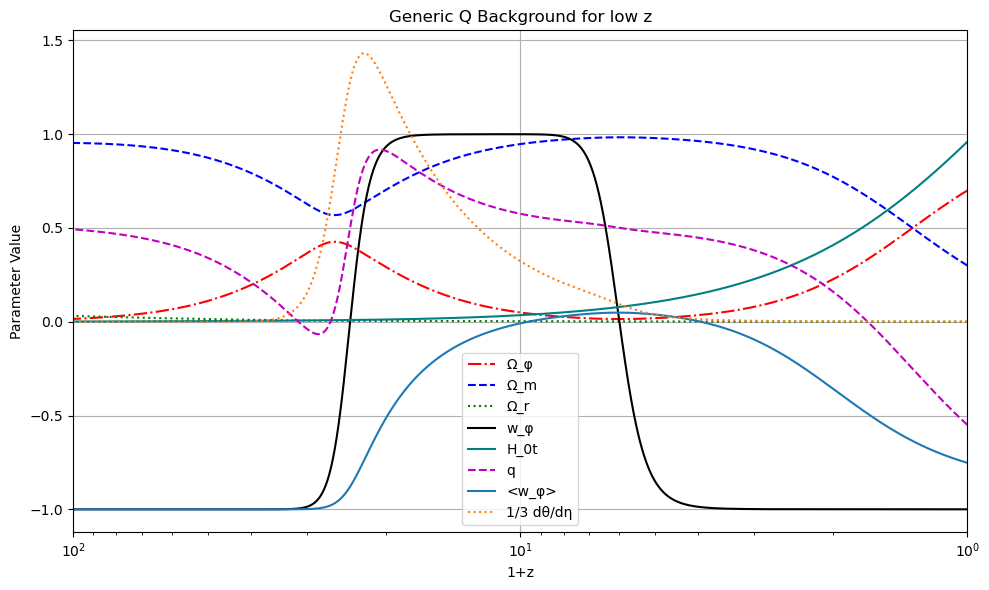

In [186]:
# Create a new plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each variable

ax.plot(oneplusz_values, Omega_phi, 
        "r-.", label='Ω_φ')
ax.plot(oneplusz_values, Omega_m, 
        "b--", label='Ω_m')
ax.plot(oneplusz_values, Omega_r, 
        "g:", label='Ω_r')
ax.plot(oneplusz_values, w_phi_values,
        "black",label='w_φ')
ax.plot(oneplusz_values, t_values, 
        "teal", label = "H_0t")
ax.plot(oneplusz_values, q, 
        "m--",label = "q")
ax.plot(oneplusz_values, w_phi_average,
       label = "<w_φ>")
ax.plot(oneplusz_values, 1/3 * dtheta_deta, 
        ":", label = "1/3 dθ/dη")


# Apply log scale to x-axis
ax.set_xscale('log')
# Reverse the x-axis
ax.set_xlim(100, min(oneplusz_values))

# Label the axes
ax.set_title("Generic Q Background for low z")
ax.set_xlabel('1+z')
ax.set_ylabel('Parameter Value')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Iterating as the square wave moves towards higher z

In [88]:
import time
start_time = time.time()

eta_0 = 0
eta_total = 5
eta_span = [0, -eta_total]
eta_eval = np.linspace(0, -eta_total, 100000)

"""
Start of the hokey stuff up here
"""
w_tolerance = 0.01

omegaphidecs = []
wavgs = []
las = []

number_of_widths = 20
width_max = 0.75
width_min = 0.1

"""
End
"""

type_of_w_function = "square"
square_wave_widths = np.linspace(width_min, width_max, number_of_widths)
z_maxes = np.linspace(20, 1100, 5)
maxws = np.linspace(1,20,5)

for sww in square_wave_widths:
    for zmax in z_maxes:
        wave_width = zmax * sww
        zmin = zmax - wave_width
        for maxw in maxws:
            height = maxw
            solution = solve_ivp(
                ode_system,
                eta_span,
                initial_state,
                t_eval = eta_eval,
                method = 'BDF',
                args = (zmin, zmax, maxw, type_of_w_function),
                rtol = 1e-10,
                atol = 1e-12
                )

            # Unpack
            rho_phi_values = solution.y[0]
            H_values = solution.y[1]
            a_values = solution.y[2]
            t_values = solution.y[3]
            hs_values = solution.y[4]

            z_values, oneplusz_values = calculate_z_vals(a_values)
            #w_phi_values = np.vectorize(calculate_w_phi_square(z_values, zmax, zmin, height))
            w_phi_values = np.vectorize(lambda z: calculate_w_phi_square(z, zmin, zmax, height))(z_values)

            # Densities
            Omega_phi, Omega_m, Omega_r = calculate_density_parameters(rho_phi_values, 
                                                                        rho_m(a_values), 
                                                                        rho_r(a_values),
                                                                        H_values)

            # w_phi_average 
            w_phi_average = calculate_w_phi_average(Omega_phi, w_phi_values, solution.t)

            # Decoupling
            idx_zdec = calculate_zDec(z_values)
            la = calculate_lA(idx_zdec, solution.t, hs_values)
            omega_phi_dec = calculate_parameter_Dec(idx_zdec, Omega_phi)

            """
            Kinda hokey, needs to be reworked, just testing it this way
            """
            omegaphidecs.append(omega_phi_dec)
            las.append(la)
            wavgs.append(w_phi_average[0])

             
            # Debugging
            """
            print(f"===For zmax {zmax} and width {wave_width:2.2f}===")
            print(f"<w_phi>: {w_phi_average[0]:2.2f}")
            #print(f"Largest value of z: {np.max(z_values):2.2f}")
            #print(f"Current Omega_m: {Omega_m[0]:2.2f}")
            print(f"Calculated lA: {la:2.2f}")
            print(f"Calculated Omega_phi_dec: {omega_phi_dec:2.2e}")
            #print(f"Friedmann check at z_dec: {Omega_m[idx_zdec]}")
            #print(f"Friedmann check at z_dec: {Omega_r[idx_zdec]}")
            #print(f"Friedmann check at z_dec: {Omega_phi[idx_zdec]}")
            print(f"Friedmann check at z_dec: {Omega_m[idx_zdec] + Omega_phi[idx_zdec] + Omega_r[idx_zdec]:2.2e}")
            print(f"Final eta: {solution.t[-1]}")
            print(solution.status, solution.message)
            """
    loop_number = (sww-width_min) / ((width_max - width_min)/number_of_widths)
    print(f"Loop number {loop_number:1.0f} of {number_of_widths} complete.")
    print(f"Time elapsed: {time.time()/60-start_time/60 :2.1f}minutes")
print("Done")

Loop number 1 of 20 complete.
Time elapsed: 0.1minutes
Loop number 2 of 20 complete.
Time elapsed: 0.2minutes
Loop number 3 of 20 complete.
Time elapsed: 0.3minutes
Loop number 4 of 20 complete.
Time elapsed: 0.4minutes
Loop number 5 of 20 complete.
Time elapsed: 0.5minutes
Loop number 6 of 20 complete.
Time elapsed: 0.6minutes
Loop number 7 of 20 complete.
Time elapsed: 0.7minutes


/tmp/ipykernel_2432/1414408931.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  return np.pi * eta_dec/hs_dec


Loop number 8 of 20 complete.
Time elapsed: 0.8minutes
Loop number 9 of 20 complete.
Time elapsed: 0.9minutes
Loop number 10 of 20 complete.
Time elapsed: 1.0minutes
Loop number 12 of 20 complete.
Time elapsed: 1.1minutes
Loop number 13 of 20 complete.
Time elapsed: 1.2minutes
Loop number 14 of 20 complete.
Time elapsed: 1.3minutes
Loop number 15 of 20 complete.
Time elapsed: 1.4minutes
Loop number 16 of 20 complete.
Time elapsed: 1.5minutes
Loop number 17 of 20 complete.
Time elapsed: 1.6minutes
Loop number 18 of 20 complete.
Time elapsed: 1.7minutes
Loop number 19 of 20 complete.
Time elapsed: 1.8minutes
Loop number 20 of 20 complete.
Time elapsed: 1.9minutes
Loop number 21 of 20 complete.
Time elapsed: 2.0minutes
Done


[0.1        0.13421053 0.16842105 0.20263158 0.23684211 0.27105263
 0.30526316 0.33947368 0.37368421 0.40789474 0.44210526 0.47631579
 0.51052632 0.54473684 0.57894737 0.61315789 0.64736842 0.68157895
 0.71578947 0.75      ]


TypeError: unsupported operand type(s) for -: 'list' and 'float'

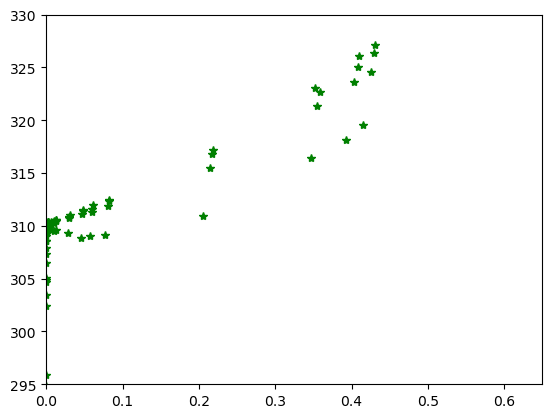

In [90]:
plt.plot(omegaphidecs, las, "g*")
plt.xlim(0,0.65)
plt.ylim(295,330)

print(square_wave_widths)
la7s = []
omegadec7s = []

def w_filter(omegaDecValues, laValues, wavg):
    outputOmegas = []
    outputLas = []
    for i in range(len(laValues)):
        if np.abs(laValues[i]-(wavg)) < w_tolerance:
            outputLas.append(laValuess[i])
            outputOmegas.append(omegaDecValues[i])
    return outputOmegas, outputLas
        
x9s, y9s = w_filter(omegaphidecs, las -0.9)

In [194]:
def calculate_observables(odeSolution):
    # Unpack
    rho_phi_values = odeSolution.y[0]
    H_values = odeSolution.y[1]
    a_values = odeSolution.y[2]
    t_values = odeSolution.y[3]
    hs_values = odeSolution.y[4]
    
    z_values, oneplusz_values = calculate_z_vals(a_values)
    """
    There's trouble right here! Pick up from the laptop version and fix this
    """
    w_phi_values = np.vectorize(lambda z: calculate_w_phi_square(z, zmin, zmax, height))(z_values)

    # Densities
    Omega_phi, Omega_m, Omega_r = calculate_density_parameters(rho_phi_values, 
                                                               rho_m(a_values), 
                                                               rho_r(a_values),
                                                               H_values)

    # Derived Quantities
    q = calculate_q(Omega_r, Omega_m, w_phi_values, Omega_phi)
    dtheta_deta = calculate_dtheta_deta(a_values, w_phi_values, rho_phi_values)

    # w_phi_average 
    w_phi_average = calculate_w_phi_average(Omega_phi, w_phi_values, odeSolution.t)

    # Decoupling
    idx_zdec = calculate_zDec(z_values)
    la = calculate_lA(idx_zdec, odeSolution.t, hs_values)

    return (
        rho_phi_values, 
        H_values,
        a_values,
        t_values,
        hs_values,
        z_values,
        oneplusz_values,
        w_phi_values,
        Omega_phi,
        Omega_m,
        Omega_r,
        q,
        dtheta_deta,
        w_phi_average,
        la
    )

In [195]:
def plot_history(data, xlim = 1100):
    [rho_phi_values, 
    H_values,
    a_values,
    t_values,
    hs_values,
    z_values,
    oneplusz_values,
    w_phi_values,
    Omega_phi,
    Omega_m,
    Omega_r,
    q,
    dtheta_deta,
    w_phi_average,
    la] = data
    
    # Create a new plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each variable

    ax.plot(oneplusz_values, Omega_phi, 
            "r-.", label='Ω_φ')
    ax.plot(oneplusz_values, Omega_m, 
            "b--", label='Ω_m')
    ax.plot(oneplusz_values, Omega_r, 
            "g:", label='Ω_r')
    ax.plot(oneplusz_values, w_phi_values,
            "black",label='w_φ')
    ax.plot(oneplusz_values, t_values, 
            "teal", label = "H_0t")
    ax.plot(oneplusz_values, q, 
            "m--",label = "q")
    ax.plot(oneplusz_values, w_phi_average,
           label = "<w_φ>")
    ax.plot(oneplusz_values, 1/3 * dtheta_deta, 
            ":", label = "1/3 dθ/dη")


    # Apply log scale to x-axis
    ax.set_xscale('log')
    # Reverse the x-axis
    ax.set_xlim(xlim, min(oneplusz_values))

    # Label the axes
    ax.set_title("Generic Q Background for low z")
    ax.set_xlabel('1+z')
    ax.set_ylabel('Parameter Value')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    print(f"la: {la}")

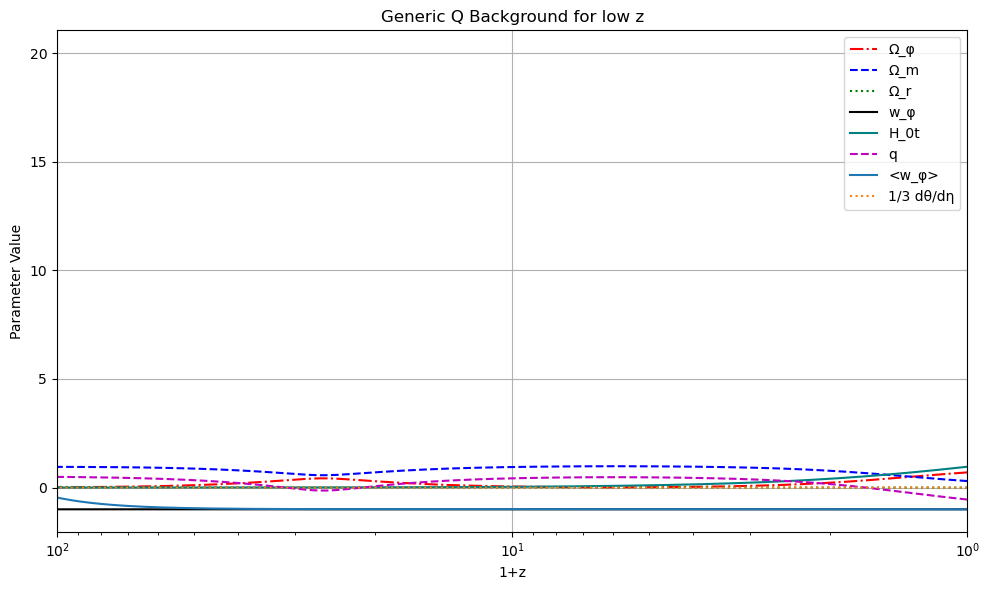

la: 302.12472122220703


In [196]:
g_sol =  solve_ivp(
    ode_system,
    eta_span,
    initial_state,
    t_eval = eta_eval,
    method = 'BDF',
    args = (5,25, 1, "smooth"),
    rtol = 1e-10,
    atol = 1e-12
    )

myData = calculate_observables(g_sol)
plot_history(myData, xlim = 100)